# Experiment No. 5

## Title
**To implement the Ellipse Drawing Algorithm for drawing an ellipse with a given center and radii**

## Objective
To generate an ellipse using the midpoint ellipse drawing algorithm and observe symmetric pixel plotting in all four quadrants.

## Theory
The Ellipse Drawing Algorithm is used in computer graphics to draw an ellipse on a raster display. An ellipse is symmetric about both the x-axis and y-axis.

For an ellipse centered at $(x_c, y_c)$ with x-radius $r_x$ and y-radius $r_y$, the standard equation is:

$$
\frac{x^2}{r_x^2} + \frac{y^2}{r_y^2} = 1
$$

The midpoint ellipse algorithm divides the ellipse into two regions.

In Region 1, the slope magnitude is less than 1, so x is increased step by step.

In Region 2, the slope magnitude is greater than 1, so y is decreased step by step.

Using symmetry, each calculated point $(x, y)$ generates four points:

- $(x_c + x,\; y_c + y)$
- $(x_c - x,\; y_c + y)$
- $(x_c + x,\; y_c - y)$
- $(x_c - x,\; y_c - y)$

This reduces calculation and makes the algorithm efficient.

## Procedure
1. Input the center of the ellipse $(x_c, y_c)$ and radii $r_x$, $r_y$.
2. Initialize $x = 0$ and $y = r_y$.
3. Calculate the first decision parameter for Region 1.
4. Generate points in Region 1 while $2r_y^2x \leq 2r_x^2y$.
5. Update the decision parameter and plot the symmetric points.
6. Calculate the second decision parameter for Region 2.
7. Generate points in Region 2 while $y \geq 0$.
8. Plot all symmetric points of the ellipse.
9. Display the generated ellipse and save the output image.

## Output
- An ellipse drawn using midpoint ellipse drawing algorithm
- Generated coordinate points in the format:
  `[(x1, y1), (x2, y2), ...]`
- Output image saved as `Exp5_Output.png`

## Result and Discussion
The Ellipse Drawing Algorithm successfully generated an ellipse using midpoint decision parameters. The plotted points showed symmetry in all four quadrants. The algorithm efficiently draws the ellipse by dividing it into two regions and using incremental calculations.

Generated Coordinates: [(10, 16), (10, 17), (10, 18), (10, 19), (10, 20), (10, 21), (10, 22), (10, 23), (10, 24), (11, 13), (11, 14), (11, 15), (11, 25), (11, 26), (11, 27), (12, 11), (12, 12), (12, 28), (12, 29), (13, 9), (13, 10), (13, 30), (13, 31), (14, 8), (14, 32), (15, 7), (15, 33), (16, 6), (16, 34), (17, 6), (17, 34), (18, 5), (18, 35), (19, 5), (19, 35), (20, 5), (20, 35), (21, 5), (21, 35), (22, 5), (22, 35), (23, 6), (23, 34), (24, 6), (24, 34), (25, 7), (25, 33), (26, 8), (26, 32), (27, 9), (27, 10), (27, 30), (27, 31), (28, 11), (28, 12), (28, 28), (28, 29), (29, 13), (29, 14), (29, 15), (29, 25), (29, 26), (29, 27), (30, 16), (30, 17), (30, 18), (30, 19), (30, 20), (30, 21), (30, 22), (30, 23), (30, 24)]


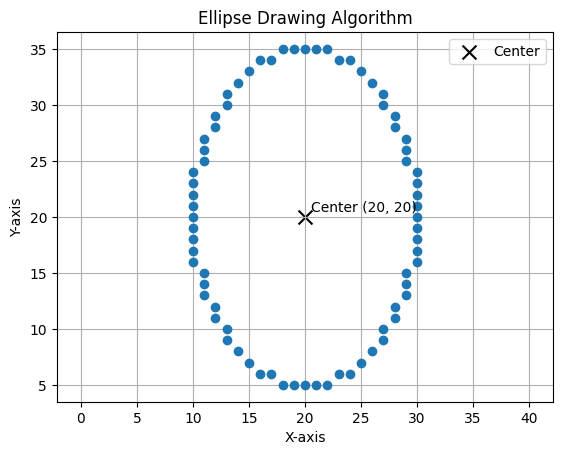

In [12]:
import matplotlib.pyplot as plt

def plot_ellipse_points(xc, yc, x, y, points):
    symmetric_points = [
        (xc + x, yc + y),
        (xc - x, yc + y),
        (xc + x, yc - y),
        (xc - x, yc - y)
    ]
    points.extend(symmetric_points)

def ellipse_drawing(xc, yc, rx, ry):
    x = 0
    y = ry

    rx2 = rx * rx
    ry2 = ry * ry

    p1 = ry2 - (rx2 * ry) + (0.25 * rx2)

    points = []
    plot_ellipse_points(xc, yc, x, y, points)

    while (2 * ry2 * x) <= (2 * rx2 * y):
        x += 1

        if p1 < 0:
            p1 = p1 + (2 * ry2 * x) + ry2
        else:
            y -= 1
            p1 = p1 + (2 * ry2 * x) - (2 * rx2 * y) + ry2

        plot_ellipse_points(xc, yc, x, y, points)

    p2 = (ry2 * (x + 0.5) ** 2) + (rx2 * (y - 1) ** 2) - (rx2 * ry2)

    while y >= 0:
        y -= 1

        if p2 > 0:
            p2 = p2 - (2 * rx2 * y) + rx2
        else:
            x += 1
            p2 = p2 + (2 * ry2 * x) - (2 * rx2 * y) + rx2

        plot_ellipse_points(xc, yc, x, y, points)

    points = list(set(points))
    points.sort()

    print("Generated Coordinates:", points)

    x_coordinates = [point[0] for point in points]
    y_coordinates = [point[1] for point in points]

    # plt.plot(x_coordinates, y_coordinates, marker="o", linestyle="None")
    # plt.title("Ellipse Drawing Algorithm")
    # plt.xlabel("X-axis")
    # plt.ylabel("Y-axis")
    # plt.grid(True)
    # plt.axis("equal")
    # plt.savefig("Exp5_Output.png")
    # plt.show()
    plt.plot(x_coordinates, y_coordinates, marker="o", linestyle="None")

    plt.scatter(xc, yc, color="black", marker="x", s=100, label="Center")
    plt.text(xc + 0.5, yc + 0.5, f"Center ({xc}, {yc})")

    plt.title("Ellipse Drawing Algorithm")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.savefig("Exp5_Output.png")
    plt.show()


# Example
ellipse_drawing(20, 20, 10, 15)